To demonstrate ``AAPredPlot().ranking()``, we rank candidate proteins by a prediction score, colored by class, with per-item error bars and confidence cut-offs:

In [1]:
import numpy as np
import pandas as pd
import aaanalysis as aa
aa.options["verbose"] = False

rng = np.random.RandomState(0)
df_pred = pd.DataFrame({
    "name":  [f"Gene{i}" for i in range(10)],
    "score": np.sort(rng.uniform(30, 95, 10)),
    "group": rng.choice(["Substrate", "Non-substrate"], 10),
    "std":   rng.uniform(1, 5, 10),
})
aa.display_df(df_pred, n_rows=10, show_shape=True)

DataFrame shape: (10, 4)


,name,score,group,std
1,Gene0,54.923699,Substrate,1.348517
2,Gene1,57.537562,Non-substrate,1.080874
3,Gene2,58.443169,Non-substrate,4.330479
4,Gene3,65.417407,Substrate,4.112627
5,Gene4,65.672878,Substrate,4.480049
6,Gene5,69.179619,Non-substrate,4.914473
7,Gene6,71.983117,Non-substrate,4.196634
8,Gene7,76.487309,Non-substrate,2.845917
9,Gene8,87.965245,Non-substrate,4.122117
10,Gene9,92.638079,Substrate,1.473098


The highest-scoring candidate is on top; the figure height grows with the number of items so each bar stays legible:

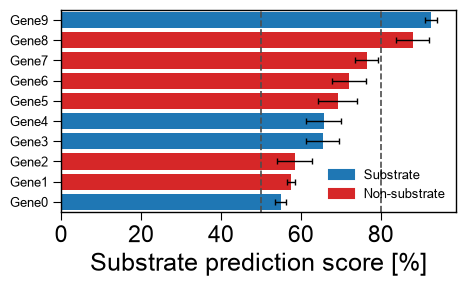

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aa.AAPredPlot().ranking(df_pred, col_group="group", col_std="std", cutoffs=(50, 80),
                        xlabel="Substrate prediction score [%]")
plt.tight_layout()
plt.show()